In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
from PIL import Image
from io import BytesIO
import pandas as pd
import time
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import random 
import tensorflow as tf
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
df1 = pd.read_csv("train_cdc.csv")
df1


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16204,5272200045,20141113T000000,378000,3,1.50,1000,6914,1.0,0,0,...,7,1000,0,1947,0,98125,47.7144,-122.319,1000,6947
16205,9578500790,20141111T000000,399950,3,2.50,3087,5002,2.0,0,0,...,8,3087,0,2014,0,98023,47.2974,-122.349,2927,5183
16206,7202350480,20140930T000000,575000,3,2.50,2120,4780,2.0,0,0,...,7,2120,0,2004,0,98053,47.6810,-122.032,1690,2650
16207,1723049033,20140620T000000,245000,1,0.75,380,15000,1.0,0,0,...,5,380,0,1963,0,98168,47.4810,-122.323,1170,15000


In [84]:
missing_indices = [612, 14961, 14962]
df1 = df1.drop(index=missing_indices).reset_index(drop=True)
print(len(os.listdir("sat_images")))
print(len(df1))


df1 = df1.drop(columns=["id","zipcode"])

df1["date"] = pd.to_datetime(df1["date"])
df1["year_sold"] = df1["date"].dt.year
df1["month_sold"] = df1["date"].dt.month
df1 = df1.drop(columns=["date"])

df1["renovated_flag"] = (df1["yr_renovated"] > 0).astype(int)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=30, random_state=42)
df1['geo_cluster'] = kmeans.fit_predict(df1[['lat','long']])
df1["house_age"] = (df1["year_sold"] - df1["yr_built"])**2

df1['log_sqft_living'] = np.log1p(df1['sqft_living'])

df1["above_ratio"] = df1["sqft_above"] / df1["sqft_living"]
eps = 1e-6

# Density proxy
df1['living_to_lot_ratio'] = df1['sqft_living'] / (df1['sqft_lot'] + eps)

16206
16206


In [85]:
df1.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'year_sold', 'month_sold',
       'renovated_flag', 'geo_cluster', 'house_age', 'log_sqft_living',
       'above_ratio', 'living_to_lot_ratio'],
      dtype='object')

In [86]:
standard_cols = [
    "bathrooms",
    "log_sqft_living",
    "sqft_basement",
    "house_age",
    "yr_renovated",
    "grade",
    "sqft_living15",
    "floors",
    "waterfront",
    "view",
    "condition",
    "bedrooms",
    "sqft_lot",
    "sqft_lot15",
    "above_ratio",
    "geo_cluster", 'living_to_lot_ratio'
]
pass_through_cols = ["lat", "long","renovated_flag",
    "price", "yr_built","year_sold","month_sold","sqft_living","sqft_above" # keep long
]


In [87]:
from sklearn.model_selection import train_test_split

# Split indices
train_idx, temp_idx = train_test_split(
    df1.index,
    test_size=0.40,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42
)

df_train = df1.loc[train_idx].reset_index(drop=True)
df_val   = df1.loc[val_idx].reset_index(drop=True)
df_test  = df1.loc[test_idx].reset_index(drop=True)


In [88]:
import numpy as np
from PIL import Image
from tensorflow.keras.applications.inception_v3 import preprocess_input

def load_and_preprocess_image(path):
    """
    Input : path to 256x256 JPG image
    Output: (299, 299, 3) float32 tensor ready for Inception-v3
    """
    img = Image.open(path).convert("RGB")   
    img = img.resize((299, 299), Image.BICUBIC)      
    img = np.array(img).astype("float32")            
    img = preprocess_input(img)                      
    return img

In [89]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

image_input = Input(shape=(299, 299, 3))

base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

base_model.trainable = False

feature_extractor = Model(image_input, base_model(image_input))


In [ ]:
import os
import numpy as np

IMAGE_DIR = "sat_images"
NUM_IMAGES = 16209
BATCH_SIZE = 32

all_embeddings = []

missing_images = 0
processed_images = 0

for start in range(0, NUM_IMAGES, BATCH_SIZE):
    end = min(start + BATCH_SIZE, NUM_IMAGES)

    batch_imgs = []
    
    for i in range(start, end):
        img_path = os.path.join(IMAGE_DIR, f"{i}.jpg")
        
        if not os.path.exists(img_path):
            missing_images += 1
            continue 
        
        try:
            img = load_and_preprocess_image(img_path)
            batch_imgs.append(img)
            processed_images += 1
        except Exception as e:
            missing_images += 1
            print(f"Skipping {img_path}: {e}")

    if len(batch_imgs) == 0:
        continue
    
    batch_imgs = np.array(batch_imgs, dtype=np.float32)
    batch_emb = feature_extractor.predict(batch_imgs, verbose=0)
    all_embeddings.append(batch_emb)

image_embeddings = np.vstack(all_embeddings)

print("Final embedding shape:", image_embeddings.shape)
print("Total processed images:", processed_images)
print("Total skipped / missing images:", missing_images)


In [ ]:
np.save("image_embeddings.npy", image_embeddings)
np.save("image_indices.npy", np.arange(NUM_IMAGES - missing_images))

In [90]:
image_embeddings = np.load("image_embeddings.npy")
image_indices = np.load("image_indices.npy")

In [91]:
X_img_train = image_embeddings[train_idx]
X_img_val   = image_embeddings[val_idx]
X_img_test  = image_embeddings[test_idx]

In [92]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

standard_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
preprocessor = ColumnTransformer(
    transformers=[
        ("std", standard_pipe, standard_cols),
        ("passthrough", "passthrough", pass_through_cols)
    ],
    remainder="drop"
)


In [93]:
X_tab_train_full = preprocessor.fit_transform(df_train)
X_tab_val_full   = preprocessor.transform(df_val)
X_tab_test_full  = preprocessor.transform(df_test)

In [94]:
final_columns = (
    standard_cols +
    pass_through_cols
)

df_tab_train = pd.DataFrame(X_tab_train_full, columns=final_columns)
df_tab_val   = pd.DataFrame(X_tab_val_full,   columns=final_columns)
df_tab_test  = pd.DataFrame(X_tab_test_full,  columns=final_columns)


In [95]:
feature_cols = [c for c in final_columns if c != "price"]

X_tab_train = df_tab_train[feature_cols].values.astype("float32")
X_tab_val   = df_tab_val[feature_cols].values.astype("float32")
X_tab_test  = df_tab_test[feature_cols].values.astype("float32")

y_train = df_tab_train["price"].values.astype("float32")
y_val   = df_tab_val["price"].values.astype("float32")
y_test  = df_tab_test["price"].values.astype("float32")



In [96]:
y_train_target = np.log1p(y_train)
y_val_target   = np.log1p(y_val)

# Neural network based approach

### 1. Feature only 

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

tabular_input = Input(shape=(X_tab_train.shape[1],), name="tabular_input")

x = Dense(128, activation="relu", kernel_regularizer=l2(1e-6))(tabular_input)
x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)

output = Dense(1, activation="linear")(x)

tab_model = Model(inputs=tabular_input, outputs=output)

tab_model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="mse",          
    metrics=["mae"]
)

tab_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tabular_input (InputLayer)      │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,697 (53.50 KB)

 Trainable params: 13,697 (53.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    ModelCheckpoint(
        "best_tabular_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]
history = tab_model.fit(
    X_tab_train,
    y_train_target,
    validation_data=(X_tab_val, y_val_target),
    epochs=500,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/500
22/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6202.3199 - mae: 58.6972  
Epoch 1: val_loss improved from None to 103.03488, saving model to best_tabular_model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1842.3687 - mae: 26.4573 - val_loss: 103.0349 - val_mae: 8.2824
Epoch 2/500
25/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 116.2855 - mae: 7.5779 
Epoch 2: val_loss improved from 103.03488 to 20.53495, saving model to best_tabular_model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 65.6991 - mae: 5.5748 - val_loss: 20.5350 - val_mae: 3.4132
Epoch 3/500
22/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 31.4025 - mae: 3.3849 
Epoch 3: val_loss improved from 20.53495 to 10.56462, saving model to best_tabular_model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.4856 - mae: 2.9288 - val_loss: 10.5646 - val_mae: 2.4182
Epoch 4/500
21/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.2438 - mae: 2.4814 
Epoch 4: val_loss improved from 10.56462 to 7.84494, savin

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

def regression_metrics(y_true, y_pred, name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} RMSE: {rmse:.2f}")
    print(f"{name} R2  : {r2:.4f}")
    print("-" * 30)
# Predictions
y_train_pred = np.expm1(tab_model.predict(X_tab_train).ravel())
y_val_pred   = np.expm1(tab_model.predict(X_tab_val).ravel())
y_test_pred  = np.expm1(tab_model.predict(X_tab_test).ravel())

# Metrics
regression_metrics(y_train, y_train_pred, "Train")
regression_metrics(y_val, y_val_pred, "Val")
regression_metrics(y_test, y_test_pred, "Test")

304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Train RMSE: 296612.54
Train R2  : 0.3186
------------------------------
Val RMSE: 329182.37
Val R2  : 0.2286
------------------------------
Test RMSE: 304434.32
Test R2  : 0.2354
------------------------------


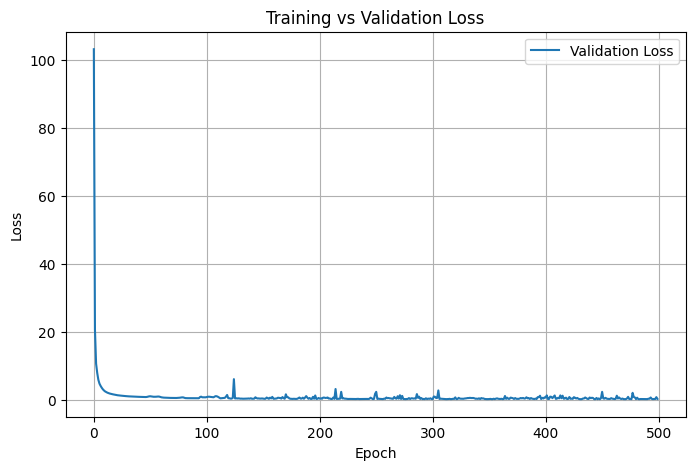

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["val_loss"], label="Validation Loss")
# plt.plot(history.history["loss"], label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# Wealth-Aware Multimodal Regression

In [97]:
low_thresh  = np.percentile(y_train, 20)
high_thresh = np.percentile(y_train, 80)
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
def wealth_label(price):
    if price <= low_thresh:
        return 0   # low value
    elif price >= high_thresh:
        return 1   # high value
    else:
        return -1  # ignore middle

wealth_y = np.array([wealth_label(p) for p in y_train])

mask = wealth_y != -1

X_img_cls = X_img_train[mask]
y_cls     = wealth_y[mask]
img_input = Input(shape=(2048,))
x = Dense(256, activation="relu")(img_input)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

cls_model = Model(img_input, output)

cls_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cls_model.summary()



Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 524,801 (2.00 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

In [98]:
checkpoint = ModelCheckpoint(
    filepath="best_fusion_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

cls_model.fit(
    X_img_cls,
    y_cls,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[checkpoint],
    verbose=1
)


Epoch 1/100
52/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6333 - loss: 0.7202
Epoch 1: val_loss improved from None to 0.50543, saving model to best_fusion_model.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6804 - loss: 0.6222 - val_accuracy: 0.7525 - val_loss: 0.5054
Epoch 2/100
53/56 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7709 - loss: 0.4914
Epoch 2: val_loss improved from 0.50543 to 0.47631, saving model to best_fusion_model.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7701 - loss: 0.4925 - val_accuracy: 0.7525 - val_loss: 0.4763
Epoch 3/100
50/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7900 - loss: 0.4591
Epoch 3: val_loss improved from 0.47631 to 0.46926, saving model to best_fusion_model.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7833 - loss: 0.4685 - val_accuracy: 0.7803 - val_loss: 0.4693
Epoch 4/100
51/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8087 - loss: 0.4266
Epoch 4: val_loss improved from 0.46926

In [99]:

from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping

In [100]:
wealth_score_train = cls_model.predict(X_img_train).flatten()
wealth_score_val   = cls_model.predict(X_img_val).flatten()
wealth_score_test  = cls_model.predict(X_img_test).flatten()
X_tab_train_aug = np.column_stack([X_tab_train, wealth_score_train])
X_tab_val_aug   = np.column_stack([X_tab_val, wealth_score_val])
X_tab_test_aug  = np.column_stack([X_tab_test, wealth_score_test])

xgb_final = XGBRegressor(
    n_estimators=450,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(
    X_tab_train_aug,
    np.log1p(y_train),
    eval_set=[(X_tab_val_aug, np.log1p(y_val))],
    verbose=50
)


304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[0]	validation_0-rmse:0.51108
[50]	validation_0-rmse:0.20850
[100]	validation_0-rmse:0.18390
[150]	validation_0-rmse:0.17640
[200]	validation_0-rmse:0.17351
[250]	validation_0-rmse:0.17194
[300]	validation_0-rmse:0.17077
[350]	validation_0-rmse:0.17032
[400]	validation_0-rmse:0.16985
[449]	validation_0-rmse:0.16968


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [101]:
y_pred = np.expm1(xgb_final.predict(X_tab_test_aug))
y_pred1 = np.expm1(xgb_final.predict(X_tab_val_aug))
y_pred2 = np.expm1(xgb_final.predict(X_tab_train_aug))

from sklearn.metrics import r2_score, mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Final RMSE test :", rmse)
print("Final R2 test:", r2)

rmse = np.sqrt(mean_squared_error(y_train, y_pred2))
r2   = r2_score(y_train, y_pred2)

print("Final RMSE train :", rmse)
print("Final R2 train:", r2)

rmse = np.sqrt(mean_squared_error(y_val, y_pred1))
r2   = r2_score(y_val, y_pred1)

print("Final RMSE val:", rmse)
print("Final R2 val:", r2)


Final RMSE test : 117538.79223473415
Final R2 test: 0.8860206007957458
Final RMSE train : 53617.74750957
Final R2 train: 0.9777340292930603
Final RMSE val: 136946.3768925633
Final R2 val: 0.8664955496788025


# Xgboost based approach 

### 1. hstacking of image and feature embedding (xgboost)

In [102]:
X_train = np.hstack([X_tab_train, X_img_train])
X_val   = np.hstack([X_tab_val,   X_img_val])
X_test  = np.hstack([X_tab_test,  X_img_test])

In [103]:
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

In [104]:
xgb_model = XGBRegressor(
    n_estimators=250,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42,
    eval_metric="rmse",
)

In [105]:
xgb_model.fit(
    X_train,
    y_train_log,
    eval_set=[(X_val, y_val_log)],
    verbose=50
)

[0]	validation_0-rmse:0.51023
[50]	validation_0-rmse:0.19888
[100]	validation_0-rmse:0.17930
[150]	validation_0-rmse:0.17675
[200]	validation_0-rmse:0.17667
[249]	validation_0-rmse:0.17703


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


In [106]:
y_test_pred_log = xgb_model.predict(X_test)
y_test_pred = np.expm1(y_test_pred_log)

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

print("XGBoost RMSE:", rmse)
print("XGBoost R2:", r2)


XGBoost RMSE: 125329.75155165672
XGBoost R2: 0.8704097867012024


In [107]:
def regression_metrics(y_true, y_pred, name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} RMSE: {rmse:.2f}")
    print(f"{name} R2  : {r2:.4f}")
    print("-" * 30)

In [108]:
y_train_pred = np.expm1(xgb_model.predict(X_train).ravel())
y_val_pred   = np.expm1(xgb_model.predict(X_val).ravel())
y_test_pred  = np.expm1(xgb_model.predict(X_test).ravel())

# Metrics
regression_metrics(y_train, y_train_pred, "Train")
regression_metrics(y_val, y_val_pred, "Val")
regression_metrics(y_test, y_test_pred, "Test")

Train RMSE: 35093.44
Train R2  : 0.9905
------------------------------
Val RMSE: 152204.75
Val R2  : 0.8351
------------------------------
Test RMSE: 125329.75
Test R2  : 0.8704
------------------------------


### 2. Xgboost on tabular only 

In [109]:
xgb_model1 = XGBRegressor(
    n_estimators=600,              
    max_depth=5,                   
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,            
    reg_alpha=0.1,                 
    reg_lambda=1.0,                
    tree_method="hist",
    random_state=42,
    eval_metric="rmse"
)

xgb_model1.fit(
    X_tab_train,
    y_train_log,
    eval_set=[(X_tab_val, y_val_log)],
    verbose=50
)


[0]	validation_0-rmse:0.51065
[50]	validation_0-rmse:0.20573
[100]	validation_0-rmse:0.17984
[150]	validation_0-rmse:0.17253
[200]	validation_0-rmse:0.16928
[250]	validation_0-rmse:0.16736
[300]	validation_0-rmse:0.16635
[350]	validation_0-rmse:0.16551
[400]	validation_0-rmse:0.16452
[450]	validation_0-rmse:0.16430
[500]	validation_0-rmse:0.16407
[550]	validation_0-rmse:0.16380
[599]	validation_0-rmse:0.16367


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


In [110]:
y_test_pred_log = xgb_model1.predict(X_tab_test)

y_test_pred = np.expm1(y_test_pred_log)
from sklearn.metrics import r2_score, mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

print("XGBoost RMSE:", rmse)
print("XGBoost R2:", r2)

XGBoost RMSE: 101921.42667761279
XGBoost R2: 0.9142972230911255


In [111]:

y_train_tab_log = xgb_model1.predict(X_tab_train)
y_val_tab_log   = xgb_model1.predict(X_tab_val)
y_test_tab_log  = xgb_model1.predict(X_tab_test)

y_train_tab = np.expm1(y_train_tab_log)
y_val_tab   = np.expm1(y_val_tab_log)
y_test_tab  = np.expm1(y_test_tab_log)

In [112]:
regression_metrics(y_train, y_train_tab, "Train")
regression_metrics(y_val, y_val_tab, "Val")
regression_metrics(y_test, y_test_tab, "Test")

Train RMSE: 66569.63
Train R2  : 0.9657
------------------------------
Val RMSE: 122859.70
Val R2  : 0.8925
------------------------------
Test RMSE: 101921.43
Test R2  : 0.9143
------------------------------


### 3. Image Residual model 

In [113]:
residual_train = y_train - y_train_tab
residual_val   = y_val   - y_val_tab
residual_test  = y_test  - y_test_tab

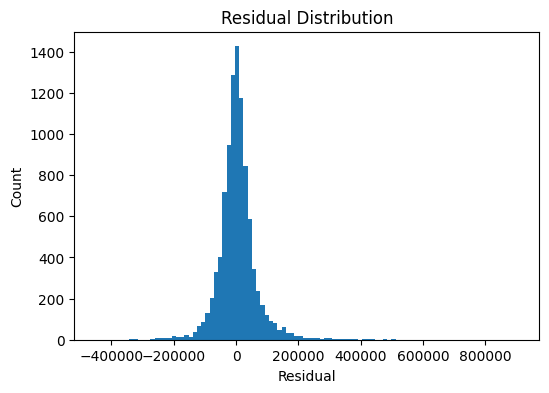

In [114]:
plt.figure(figsize=(6,4))
plt.hist(residual_train, bins=100)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()


In [115]:
residual_model = XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

residual_model.fit(
    X_img_train,
    residual_train,
    eval_set=[(X_img_val, residual_val)],
    verbose=50
)


[0]	validation_0-rmse:122609.51008
[50]	validation_0-rmse:122026.22732
[100]	validation_0-rmse:121705.00519
[149]	validation_0-rmse:121629.11167


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [116]:
residual_pred_test = residual_model.predict(X_img_test)
residual_pred_train = residual_model.predict(X_img_train)
residual_pred_val = residual_model.predict(X_img_val)
y_final_pred1 = y_test_tab + residual_pred_test
y_final_pred2 = y_val_tab + residual_pred_val


In [117]:
y_final_pred3 = y_train_tab + residual_pred_train

In [118]:
regression_metrics(y_train, y_final_pred3, "Train")
regression_metrics(y_val, y_final_pred2, "Val")
regression_metrics(y_test, y_final_pred1, "Test")

Train RMSE: 54394.32
Train R2  : 0.9771
------------------------------
Val RMSE: 121629.12
Val R2  : 0.8947
------------------------------
Test RMSE: 101651.73
Test R2  : 0.9148
------------------------------


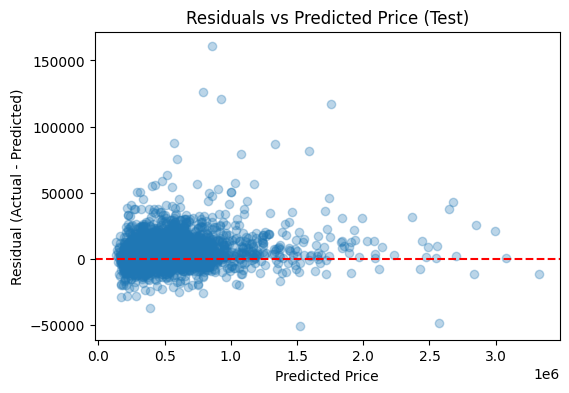

In [119]:

plt.figure(figsize=(6,4))
plt.scatter(y_final_pred1, residual_pred_test, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Price (Test)")
plt.show()


### Prediction on test file 

In [120]:
df2 = pd.read_csv("test_cdc.csv")

In [121]:
test_ids = df2["id"].values

In [138]:
df2

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_living15,sqft_lot15,year_sold,month_sold,renovated_flag,geo_cluster,house_age,log_sqft_living,above_ratio,living_to_lot_ratio
0,2591820310,4,2.25,2070,8893,2.0,0,0,4,8,...,2390,7700,2014,10,0,20,784,7.635787,1.000000,0.232767
1,7974200820,5,3.00,2900,6730,1.0,0,0,5,8,...,2370,6283,2014,8,0,14,1369,7.972811,0.631034,0.430906
2,7701450110,4,2.50,3770,10893,2.0,0,2,3,11,...,3710,9685,2014,8,0,12,289,8.235095,1.000000,0.346094
3,9522300010,3,3.50,4560,14608,2.0,0,2,3,12,...,4050,14226,2015,3,0,8,625,8.425297,1.000000,0.312158
4,9510861140,3,2.50,2550,5376,2.0,0,0,3,9,...,2250,4050,2014,7,0,4,100,7.844241,1.000000,0.474330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399,7732500270,4,2.50,2820,15000,2.0,0,0,4,9,...,2440,15000,2014,9,0,21,841,7.944847,1.000000,0.188000
5400,3856903515,3,2.00,1460,6250,1.5,0,0,4,7,...,1690,4750,2014,12,0,14,10404,7.286876,1.000000,0.233600
5401,2557000400,3,2.50,2070,9900,1.0,0,0,3,8,...,2070,8250,2015,4,0,0,1296,7.635787,0.685990,0.209091
5402,4386700135,4,2.25,4760,8036,2.5,0,0,5,9,...,2950,9323,2014,11,0,14,9604,8.468213,0.712185,0.592334


In [ ]:

IMAGE_DIR = "sat1_images"
NUM_IMAGES = 5404
BATCH_SIZE = 32

all_embeddings = []

missing_images = 0
processed_images = 0

for start in range(0, NUM_IMAGES, BATCH_SIZE):
    end = min(start + BATCH_SIZE, NUM_IMAGES)

    batch_imgs = []
    
    for i in range(start, end):
        img_path = os.path.join(IMAGE_DIR, f"{i}.jpg")
        
        if not os.path.exists(img_path):
            missing_images += 1
            continue 
        
        try:
            img = load_and_preprocess_image(img_path)
            batch_imgs.append(img)
            processed_images += 1
        except Exception as e:
            missing_images += 1
            print(f"Skipping {img_path}: {e}")

    if len(batch_imgs) == 0:
        continue
    
    batch_imgs = np.array(batch_imgs, dtype=np.float32)
    batch_emb = feature_extractor.predict(batch_imgs, verbose=0)
    all_embeddings.append(batch_emb)

image_embeddings = np.vstack(all_embeddings)

print("Final embedding shape:", image_embeddings.shape)
print("Total processed images:", processed_images)
print("Total skipped / missing images:", missing_images)


In [ ]:
np.save("image_embeddings_pred.npy", image_embeddings)
np.save("image_indices_pred.npy", np.arange(NUM_IMAGES - missing_images))

In [122]:
image_embeddings1 = np.load("image_embeddings_pred.npy")
image_indices1 = np.load("image_indices_pred.npy")

In [123]:
df2 = df2.drop(columns=["zipcode"])
df2["date"] = pd.to_datetime(df2["date"])

df2["year_sold"]  = df2["date"].dt.year
df2["month_sold"] = df2["date"].dt.month

df2 = df2.drop(columns=["date"])
df2["renovated_flag"] = (df2["yr_renovated"] > 0).astype(int)

# Use trained KMeans (DO NOT fit again)
df2["geo_cluster"] = kmeans.predict(df2[["lat", "long"]])

df2["house_age"] = (df2["year_sold"] - df2["yr_built"]) ** 2

df2["log_sqft_living"] = np.log1p(df2["sqft_living"])

eps = 1e-6
df2["above_ratio"] = df2["sqft_above"] / (df2["sqft_living"] + eps)

df2["living_to_lot_ratio"] = df2["sqft_living"] / (df2["sqft_lot"] + eps)
df2_model = df2.drop(columns=["id"])
df2_model["price"] = 0.0

In [124]:
X1_final = preprocessor.transform(df2_model)

In [125]:
X1_final

array([[ 1.83018022e-01,  2.03456307e-01, -6.62331869e-01, ...,
         1.00000000e+01,  2.07000000e+03,  2.07000000e+03],
       [ 1.16851787e+00,  9.99103174e-01,  1.74774125e+00, ...,
         8.00000000e+00,  2.90000000e+03,  1.83000000e+03],
       [ 5.11517970e-01,  1.61830554e+00, -6.62331869e-01, ...,
         8.00000000e+00,  3.77000000e+03,  3.77000000e+03],
       ...,
       [ 5.11517970e-01,  2.03456307e-01,  8.01731238e-01, ...,
         4.00000000e+00,  2.07000000e+03,  1.42000000e+03],
       [ 1.83018022e-01,  2.16864991e+00,  2.42346268e+00, ...,
         1.10000000e+01,  4.76000000e+03,  3.39000000e+03],
       [-4.73981876e-01, -2.33589741e-01, -6.62331869e-01, ...,
         5.00000000e+00,  1.72000000e+03,  1.72000000e+03]],
      shape=(5404, 26))

In [126]:
df_final = pd.DataFrame(
    X1_final,
    columns=final_columns
)


In [127]:
df_final

,bathrooms,log_sqft_living,sqft_basement,house_age,yr_renovated,grade,sqft_living15,floors,waterfront,view,...,living_to_lot_ratio,lat,long,renovated_flag,price,yr_built,year_sold,month_sold,sqft_living,sqft_above
0,0.183018,0.203456,-0.662332,-0.635846,-0.208474,0.296030,0.590804,0.941541,-0.088759,-0.311564,...,-0.327722,47.4388,-122.162,0.0,0.0,1986.0,2014.0,10.0,2070.0,2070.0
1,1.168518,0.999103,1.747741,-0.448253,-0.208474,0.296030,0.561578,-0.914812,-0.088759,-0.311564,...,0.400862,47.6784,-122.285,0.0,0.0,1977.0,2014.0,8.0,2900.0,1830.0
2,0.511518,1.618306,-0.662332,-0.794579,-0.208474,2.856791,2.519757,0.941541,-0.088759,2.284272,...,0.088995,47.5646,-122.129,0.0,0.0,1997.0,2014.0,8.0,3770.0,3770.0
3,1.825518,2.067334,-0.662332,-0.686833,-0.208474,3.710378,3.016608,0.941541,-0.088759,2.284272,...,-0.035793,47.6995,-122.228,0.0,0.0,1990.0,2015.0,3.0,4560.0,4560.0
4,0.511518,0.695575,-0.662332,-0.855186,-0.208474,1.149617,0.386219,0.941541,-0.088759,-0.311564,...,0.560538,47.6647,-122.083,0.0,0.0,2004.0,2014.0,7.0,2550.0,2550.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399,0.511518,0.933086,-0.662332,-0.617568,-0.208474,1.149617,0.663871,0.941541,-0.088759,-0.311564,...,-0.492338,47.7255,-122.101,0.0,0.0,1985.0,2014.0,9.0,2820.0,2820.0
5400,-0.145482,-0.620252,-0.662332,2.449018,-0.208474,-0.557558,-0.432125,0.013365,-0.088759,-0.311564,...,-0.324660,47.6693,-122.333,0.0,0.0,1912.0,2014.0,12.0,1460.0,1460.0
5401,0.511518,0.203456,0.801731,-0.471662,-0.208474,0.296030,0.123180,-0.914812,-0.088759,-0.311564,...,-0.414783,47.2988,-122.371,0.0,0.0,1979.0,2015.0,4.0,2070.0,1420.0
5402,0.183018,2.168650,2.423463,2.192480,-0.208474,1.149617,1.409148,1.869717,-0.088759,-0.311564,...,0.994456,47.6415,-122.285,0.0,0.0,1916.0,2014.0,11.0,4760.0,3390.0


In [128]:
X_test_final = (
    df_final[feature_cols]
    .values
    .astype("float32")
)


In [129]:
X_test_final

array([[ 1.8301803e-01,  2.0345631e-01, -6.6233188e-01, ...,
         1.0000000e+01,  2.0700000e+03,  2.0700000e+03],
       [ 1.1685178e+00,  9.9910319e-01,  1.7477412e+00, ...,
         8.0000000e+00,  2.9000000e+03,  1.8300000e+03],
       [ 5.1151794e-01,  1.6183056e+00, -6.6233188e-01, ...,
         8.0000000e+00,  3.7700000e+03,  3.7700000e+03],
       ...,
       [ 5.1151794e-01,  2.0345631e-01,  8.0173123e-01, ...,
         4.0000000e+00,  2.0700000e+03,  1.4200000e+03],
       [ 1.8301803e-01,  2.1686499e+00,  2.4234626e+00, ...,
         1.1000000e+01,  4.7600000e+03,  3.3900000e+03],
       [-4.7398189e-01, -2.3358974e-01, -6.6233188e-01, ...,
         5.0000000e+00,  1.7200000e+03,  1.7200000e+03]],
      shape=(5404, 25), dtype=float32)

In [130]:
y_test_pred_log = xgb_model1.predict(X_test_final)

y_test_pred = np.expm1(y_test_pred_log) 
# Prediction from xgboost model 

In [131]:
residual_pred_test1 = residual_model.predict(image_embeddings1)
y_final_pred = y_test_pred + residual_pred_test1
# Prediction from residual model 

In [132]:
y_final_pred

array([ 364436.84,  828813.75, 1120944.1 , ...,  274074.53, 1773252.8 ,
        317974.44], shape=(5404,), dtype=float32)

In [133]:
submission = pd.DataFrame({
    "id": test_ids,
    "predicted_price": y_final_pred
})

In [134]:
submission.to_csv("test_predictions.csv", index=False)
print("Saved: test_predictions.csv")


Saved: test_predictions.csv


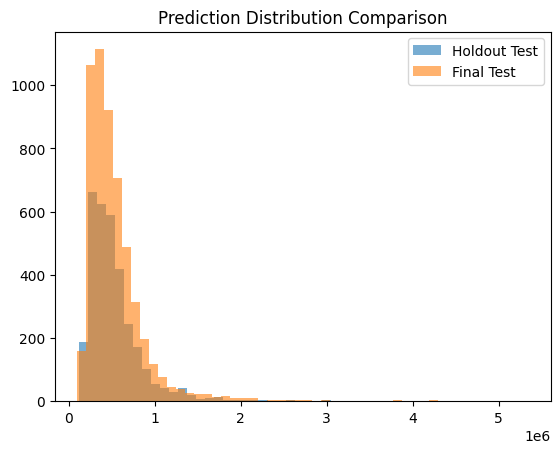

In [135]:
import matplotlib.pyplot as plt

plt.hist(y_final_pred2, bins=50, alpha=0.6, label="Holdout Test")
plt.hist(y_final_pred, bins=50, alpha=0.6, label="Final Test")
plt.legend()
plt.title("Prediction Distribution Comparison")
plt.show()


In [136]:
print("Mean ratio (final / holdout):",
      np.mean(y_final_pred1) / np.mean(y_final_pred))

print("Std ratio (final / holdout):",
      np.std(y_final_pred1) / np.std(y_final_pred))

Mean ratio (final / holdout): 0.97683996
Std ratio (final / holdout): 0.87406504


In [137]:
import numpy as np

def describe_preds(name, y):
    return {
        "set": name,
        "mean": np.mean(y),
        "std": np.std(y),
        "min": np.min(y),
        "p5": np.percentile(y, 5),
        "p25": np.percentile(y, 25),
        "median": np.percentile(y, 50),
        "p75": np.percentile(y, 75),
        "p95": np.percentile(y, 95),
        "max": np.max(y),
    }

train_test_stats = describe_preds("holdout_test", y_final_pred3)
final_test_stats = describe_preds("final_test", y_final_pred)

train_test_stats, final_test_stats


({'set': 'holdout_test',
  'mean': np.float32(540388.7),
  'std': np.float32(349063.7),
  'min': np.float32(83492.46),
  'p5': np.float32(222996.73),
  'p25': np.float32(325542.06),
  'median': np.float32(461301.34),
  'p75': np.float32(638819.44),
  'p95': np.float32(1110960.5),
  'max': np.float32(7352515.0)},
 {'set': 'final_test',
  'mean': np.float32(541344.6),
  'std': np.float32(370104.22),
  'min': np.float32(100906.9),
  'p5': np.float32(220930.64),
  'p25': np.float32(322795.4),
  'median': np.float32(454944.9),
  'p75': np.float32(643027.8),
  'p95': np.float32(1116190.4),
  'max': np.float32(5337361.5)})